# Predictive Maintenance of Engines using RUL Estimation
This notebook covers the data preprocessing, exploratory analysis, and modeling for predicting the Remaining Useful Life (RUL) of engines based on sensor data.

## Import Necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# Dataset
The dataset consists of multivariate time series data collected from a fleet of engines under varying operational conditions and fault modes. Key takeaways:

#### - Train Data:
- Includes complete degradation cycles for engines until failure.
#### - Test Data:
- Contains partial degradation cycles (not up to failure).
- The goal is to predict the Remaining Useful Life (RUL) for each engine at the end of its test cycle.
#### - Operational Settings:
- Impact engine behavior, introducing variability.
#### - Sensors:
- Capture engine health over time (potentially noisy).


### Load the data

In [3]:
# Load the training data
train_data = pd.read_csv(r'C:\Users\maika\OneDrive\Desktop\projects\EngineAnomalyDetection\DATASET\train_FD001.txt', sep=' ', header=None)
train_data.dropna(axis=1, inplace=True)  # Remove empty columns
train_data.columns = ['Unit', 'Time'] + \
    [f'Op_Setting_{i}' for i in range(1, 4)] + \
    [f'Sensor_{i}' for i in range(1, 22)]

# Load the test data
test_data = pd.read_csv(r'C:\Users\maika\OneDrive\Desktop\projects\EngineAnomalyDetection\DATASET\test_FD001.txt', sep=' ', header=None)
test_data.dropna(axis=1, inplace=True)
test_data.columns = train_data.columns

'''# Handle FutureWarning by converting to float
train_data.iloc[:, 2:24] = train_data.iloc[:, 2:24].astype(float)
test_data.iloc[:, 2:24] = test_data.iloc[:, 2:24].astype(float)'''

# Load the RUL values
rul_data = pd.read_csv(r'C:\Users\maika\OneDrive\Desktop\projects\EngineAnomalyDetection\DATASET\RUL_FD001.txt', header=None)
rul_data.columns = ['RUL']


### Data Preprocessing
- label engineering 
- normalization 
- feautre selection 


In [4]:
# Calculate the RUL for the training data 
train_data['RUL'] = train_data.groupby('Unit')['Time'].transform(lambda x: x.max() - x)




In [5]:
# scale the op_setting and sensor data
scaler = MinMaxScaler()
train_data.iloc[:, 2:24] = scaler.fit_transform(train_data.iloc[:, 2:24])
test_data.iloc[:, 2:24] = scaler.transform(test_data.iloc[:, 2:24])


C:\Users\maika\AppData\Local\Temp\ipykernel_5852\1767953218.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.33333333 0.33333333 0.16666667 ... 0.83333333 0.58333333 0.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_data.iloc[:, 2:24] = scaler.fit_transform(train_data.iloc[:, 2:24])
C:\Users\maika\AppData\Local\Temp\ipykernel_5852\1767953218.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.33333333 0.41666667 0.41666667 ... 0.58333333 0.58333333 0.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_data.iloc[:, 2:24] = scaler.transform(test_data.iloc[:, 2:24])


In [6]:
#feature selection, analyze the importance of each sensor
train_data.var().sort_values()

# Drop the columns with low variance (below a threshold)



Sensor_1           0.000000
Op_Setting_3       0.000000
Sensor_10          0.000000
Sensor_5           0.000000
Sensor_19          0.000000
Sensor_16          0.000000
Sensor_18          0.000000
Sensor_14          0.009691
Sensor_9           0.009819
Sensor_13          0.011186
Sensor_8           0.011568
Sensor_21          0.011718
Op_Setting_1       0.015802
Sensor_17          0.016657
Sensor_3           0.017866
Sensor_6           0.019293
Sensor_7           0.020314
Sensor_15          0.020824
Sensor_2           0.022686
Sensor_4           0.023084
Sensor_12          0.024731
Sensor_11          0.025275
Sensor_20          0.032669
Op_Setting_2       0.059643
Unit             854.254525
RUL             4744.590808
Time            4744.590808
dtype: float64

### Data analysis

In [7]:
# check for missing values
print(train_data.isnull().sum())  # Ensure there are no missing values


Unit            0
Time            0
Op_Setting_1    0
Op_Setting_2    0
Op_Setting_3    0
Sensor_1        0
Sensor_2        0
Sensor_3        0
Sensor_4        0
Sensor_5        0
Sensor_6        0
Sensor_7        0
Sensor_8        0
Sensor_9        0
Sensor_10       0
Sensor_11       0
Sensor_12       0
Sensor_13       0
Sensor_14       0
Sensor_15       0
Sensor_16       0
Sensor_17       0
Sensor_18       0
Sensor_19       0
Sensor_20       0
Sensor_21       0
RUL             0
dtype: int64


data visualisation 

### RUL Distribution (Histogram)

The histogram below shows the distribution of Remaining Useful Life (RUL) for both the training and test datasets. RUL represents the number of remaining operational cycles before the engine reaches failure.

#### What is expected:
- **Train RUL (blue)**: This histogram shows how RUL values are distributed in the training set, indicating how many engines are still operational and how many are closer to failure.
- **Test RUL (red)**: Similarly, this histogram shows the RUL distribution for the test set. It is important to observe if there is a similar distribution between the training and test sets, which may affect how the model generalizes.

From this histogram, we can identify if most engines have a long remaining life or if there are many engines near failure.


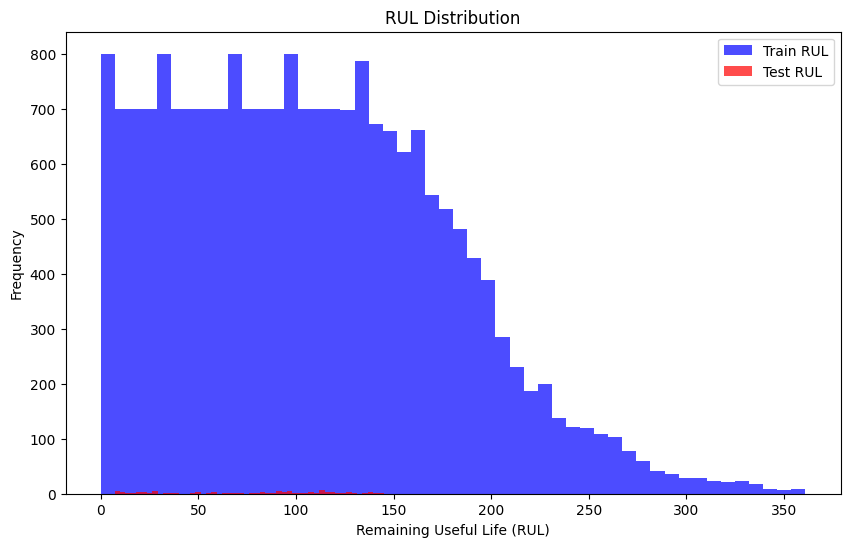

In [8]:
# Plot RUL distribution for the training data
# shows how the Remaining Useful Life (RUL) values are spread across the data
plt.figure(figsize=(10, 6))
plt.hist(train_data['RUL'], bins=50, color='blue', alpha=0.7, label='Train RUL')
plt.hist(rul_data['RUL'], bins=50, color='red', alpha=0.7, label='Test RUL')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Frequency')
plt.title('RUL Distribution')
plt.legend()
plt.show()


### Sensor Data Over Time (Line Plots)

The following line plots show how sensor readings change over time for a specific engine unit (e.g., `Unit = 1`). Each line represents a different sensor, showing how its values fluctuate across operational cycles.

#### What is expected:
- The x-axis represents **Time** (in cycles), and the y-axis represents the **sensor readings** for each of the sensors.
- By visualizing these trends, you can see which sensors are more sensitive to degradation and which ones maintain stable readings over time.
- Sudden drops or spikes in the sensor readings may indicate anomalies or potential issues that could lead to failure.
- You should also observe which sensors show clear degradation patterns, as these sensors might be more valuable for predicting RUL.

This plot helps identify which sensor readings are associated with engine health and failure.


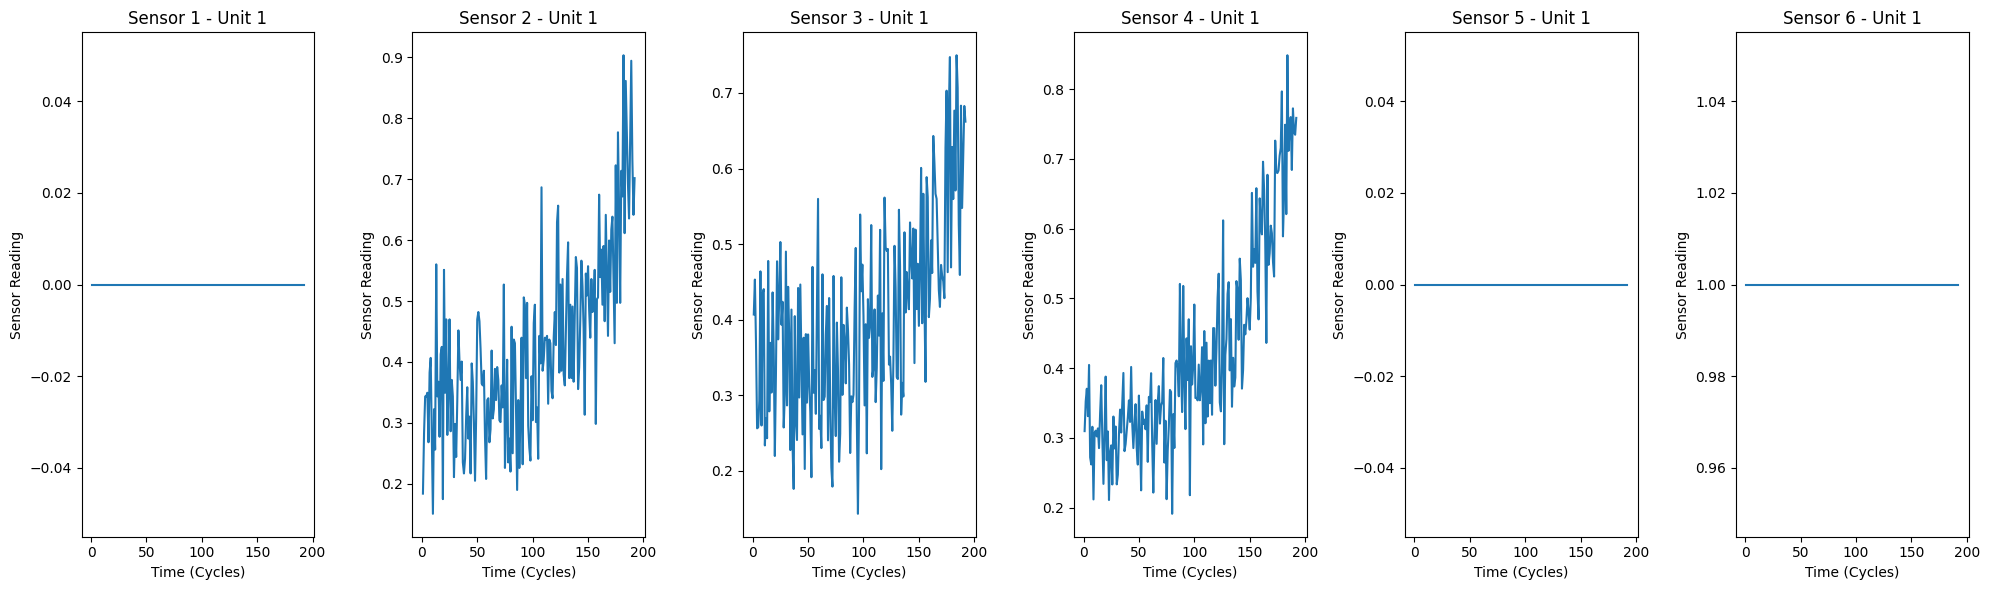

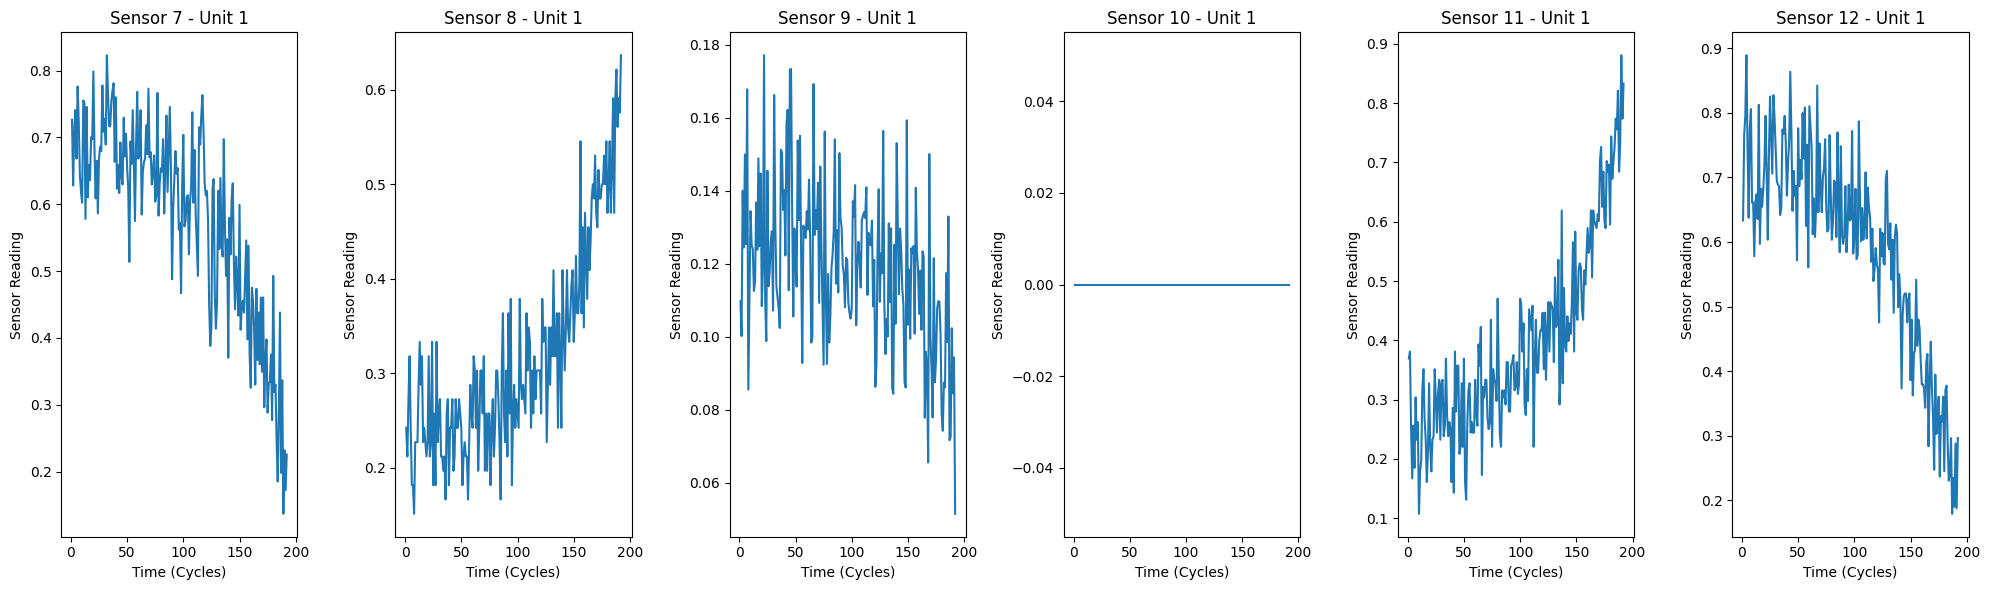

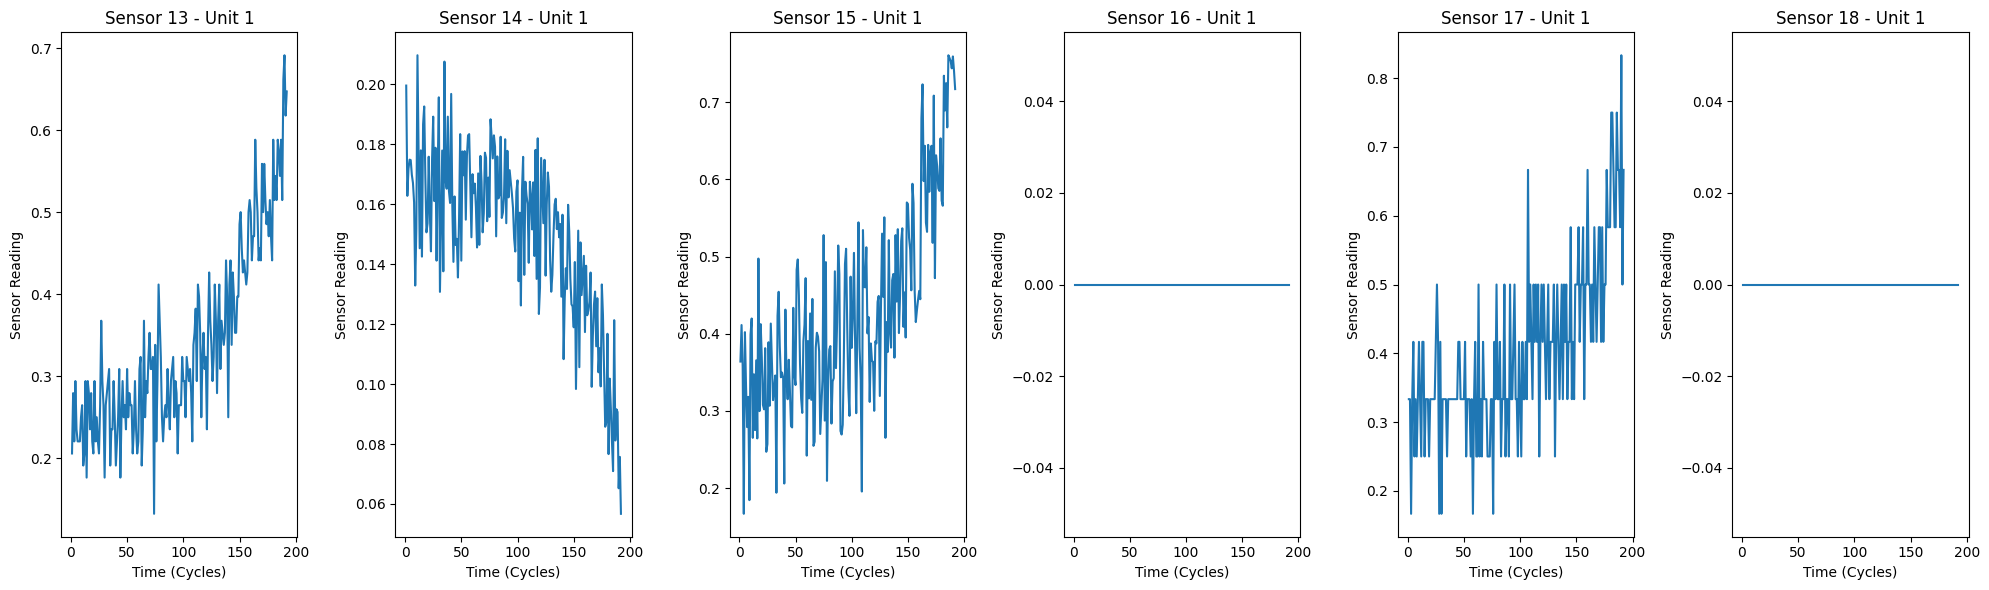

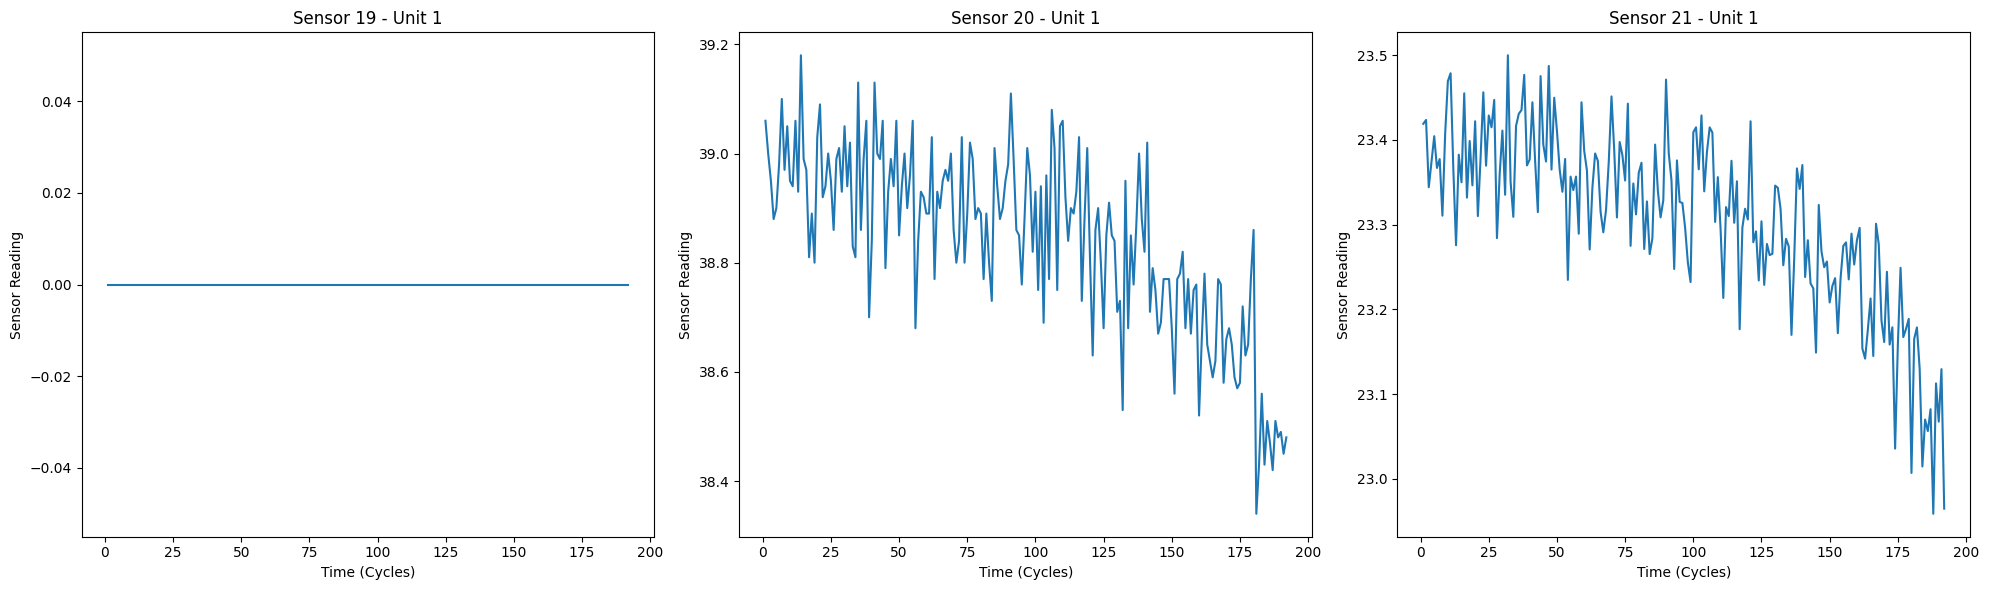

In [9]:

# Define the unit number for a specific engine (for example, unit 1)
unit_number = 1

# Filter data for this specific unit
unit_data = train_data[train_data['Unit'] == unit_number]

# Define sensor groups
sensor_groups = [
    [1, 2, 3, 4, 5, 6], 
    [7, 8, 9, 10, 11, 12], 
    [13, 14, 15, 16, 17, 18], 
    [19, 20, 21]
]

# Loop through each group of sensors
for group in sensor_groups:
    num_sensors = len(group)
    # Create a subplot for each group
    fig, axes = plt.subplots(nrows=1, ncols=num_sensors, figsize=(20, 6))
    
    if num_sensors == 1:
        axes = [axes]
    
    for i, sensor in enumerate(group):
        ax = axes[i]
        ax.plot(unit_data['Time'], unit_data[f'Sensor_{sensor}'])
        ax.set_title(f'Sensor {sensor} - Unit {unit_number}')
        ax.set_xlabel('Time (Cycles)')
        ax.set_ylabel('Sensor Reading')

    # Adjust layout for each group plot
    plt.tight_layout()
    plt.show()


In [10]:
# List of sensors to drop based on your observation
sensors_to_drop = ['Sensor_1', 'Sensor_5', 'Sensor_6', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']

# Drop the identified sensors from the dataset
train_data = train_data.drop(columns=sensors_to_drop)
test_data = test_data.drop(columns=sensors_to_drop)

# Verify that the sensors are dropped
print(f'Dropped sensors: {sensors_to_drop}')
print(f'Updated training data shape: {train_data.shape}')
print(f'Updated test data shape: {test_data.shape}')


Dropped sensors: ['Sensor_1', 'Sensor_5', 'Sensor_6', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']
Updated training data shape: (20631, 20)
Updated test data shape: (13096, 19)


### Correlation Matrix (Heatmap)

The correlation matrix below shows the relationships between different sensors and operational settings. Each cell in the matrix represents the correlation between two variables, where values range from -1 (perfect negative correlation) to +1 (perfect positive correlation).

#### What is expected:
- **High positive correlations** (red cells) suggest that two features move together. For example, when one sensor increases in value, the other sensor does too.
- **Low or zero correlations** (white cells) mean that the features are largely independent of each other and provide different information.
- **Negative correlations** (blue cells) indicate that when one feature increases, the other decreases.
  
The goal of this heatmap is to identify redundant features (those with high correlations) and assess which features are most informative for predicting engine failures. Highly correlated features may be dropped during feature selection to simplify the model.


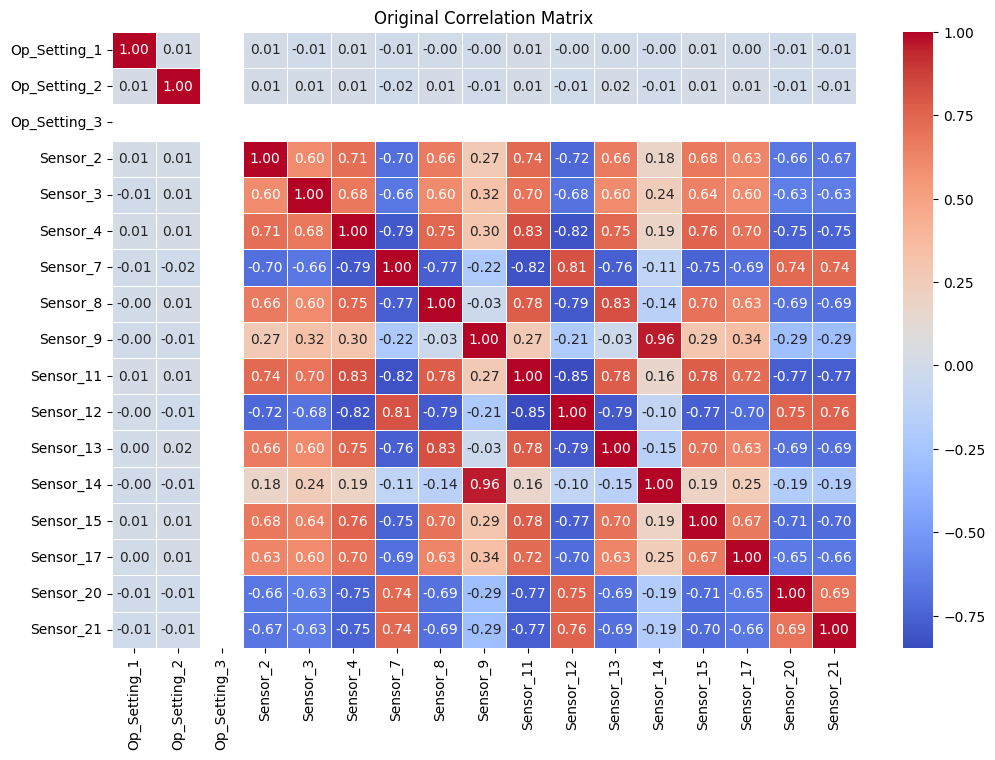

Dropped Features due to high correlation: {'Sensor_9', 'Sensor_14'}


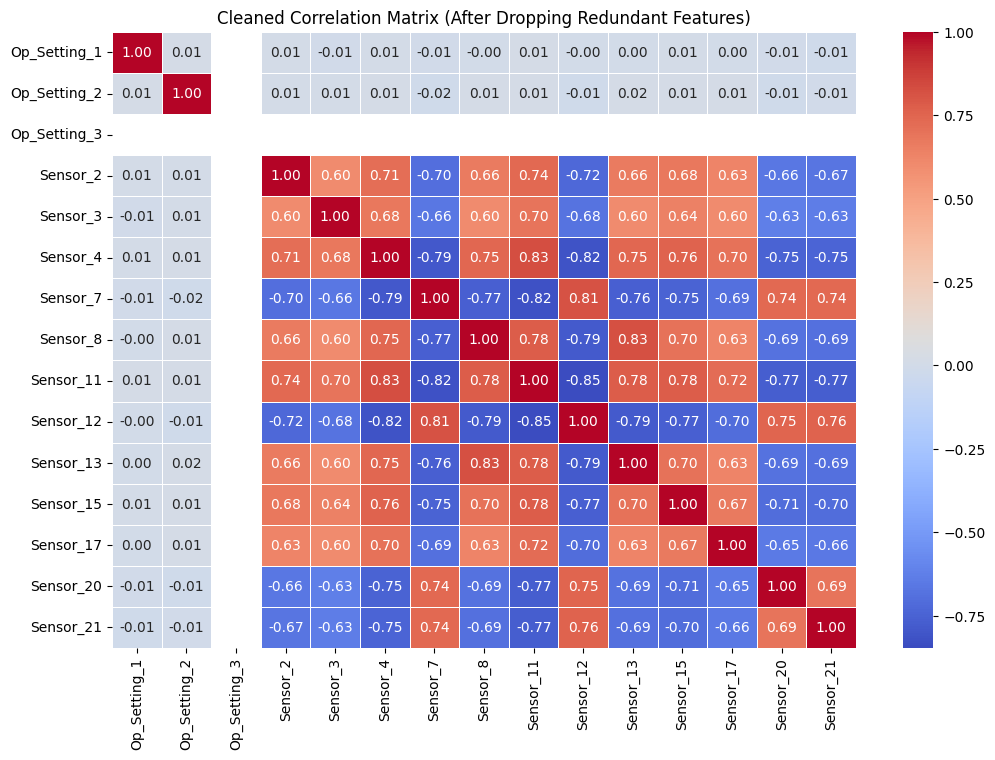

In [11]:


# Calculate the correlation matrix (excluding 'Unit', 'Time', and 'RUL')
correlation_matrix = train_data.iloc[:, 2:-1].corr()

# Plot the correlation heatmap before dropping
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Original Correlation Matrix')
plt.show()

# Step 1: Identify highly correlated features (correlation > 0.9)
threshold = 0.90
high_corr_var = np.where(np.abs(correlation_matrix) >= threshold)

# Step 2: Create a list of columns to drop
high_corr_columns = set()
for i, j in zip(*high_corr_var):
    if i != j:  # Ignore the diagonal (correlation with itself)
        high_corr_columns.add(correlation_matrix.columns[i])

# Print dropped columns
print(f"Dropped Features due to high correlation: {high_corr_columns}")

# Step 3: Drop highly correlated columns
train_data_cleaned = train_data.drop(columns=high_corr_columns)

# Replot the cleaned correlation matrix to verify that high correlations have been removed
corr_matrix_cleaned = train_data_cleaned.iloc[:, 2:-1].corr()

# Plot the correlation heatmap after dropping
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Cleaned Correlation Matrix (After Dropping Redundant Features)')
plt.show()


### RUL vs Time (Line Plot)

The plot below shows how Remaining Useful Life (RUL) changes over time (cycles) for a specific engine unit (e.g., `Unit = 1`). This plot visualizes how the remaining operational life of the engine decreases as it approaches failure.

#### What is expected:
- The x-axis represents **Time** (in cycles), and the y-axis represents the **Remaining Useful Life (RUL)** of the engine.
- Typically, RUL decreases over time, reflecting the degradation of the engine.
- **Steady RUL** values indicate that the engine is still operating well, whereas a **sharp decrease** in RUL signifies rapid degradation and the potential for failure.

This plot is essential for understanding how the engine’s health evolves over time, helping to predict when an engine will fail and how much operational time remains.


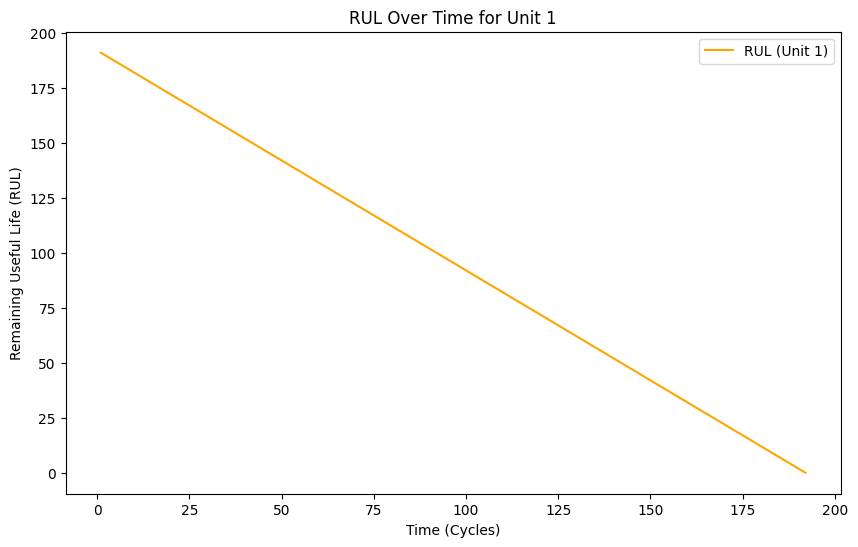

In [12]:
# Plot RUL over time for a specific engine
plt.figure(figsize=(10, 6))
unit_1_rul = train_data[train_data['Unit'] == 1]
plt.plot(unit_1_rul['Time'], unit_1_rul['RUL'], label='RUL (Unit 1)', color='orange')
plt.xlabel('Time (Cycles)')
plt.ylabel('Remaining Useful Life (RUL)')
plt.title('RUL Over Time for Unit 1')
plt.legend()
plt.show()


In [13]:
# Check if the 'Unit' column is correctly assigned and that there is data for each unit
print(train_data['Unit'].value_counts())
unit_counts = train_data.groupby('Unit').size()
print(unit_counts)


Unit
69    362
92    341
96    336
67    313
83    293
     ... 
58    147
70    137
57    137
91    135
39    128
Name: count, Length: 100, dtype: int64
Unit
1      192
2      287
3      179
4      189
5      269
      ... 
96     336
97     202
98     156
99     185
100    200
Length: 100, dtype: int64


In [14]:
print(train_data.head())


   Unit  Time  Op_Setting_1  Op_Setting_2  Op_Setting_3  Sensor_2  Sensor_3  \
0     1     1      0.459770      0.166667           0.0  0.183735  0.406802   
1     1     2      0.609195      0.250000           0.0  0.283133  0.453019   
2     1     3      0.252874      0.750000           0.0  0.343373  0.369523   
3     1     4      0.540230      0.500000           0.0  0.343373  0.256159   
4     1     5      0.390805      0.333333           0.0  0.349398  0.257467   

   Sensor_4  Sensor_7  Sensor_8  Sensor_9  Sensor_11  Sensor_12  Sensor_13  \
0  0.309757  0.726248  0.242424  0.109755   0.369048   0.633262   0.205882   
1  0.352633  0.628019  0.212121  0.100242   0.380952   0.765458   0.279412   
2  0.370527  0.710145  0.272727  0.140043   0.250000   0.795309   0.220588   
3  0.331195  0.740741  0.318182  0.124518   0.166667   0.889126   0.294118   
4  0.404625  0.668277  0.242424  0.149960   0.255952   0.746269   0.235294   

   Sensor_14  Sensor_15  Sensor_17  Sensor_20  Sensor_21

### Data cleaning and splitting

In [15]:
# Get a list of unique units
units = train_data['Unit'].unique()

# Split the units into training and validation sets (e.g., 80% for training and 20% for validation)
train_units, val_units = train_test_split(units, test_size=0.2, random_state=42)

# Create training and validation sets based on the unit split
train_data_split = train_data[train_data['Unit'].isin(train_units)]
val_data_split = train_data[train_data['Unit'].isin(val_units)]




# Model


In [16]:
def create_sequences(data, sequence_length=30):
    sequences = []
    labels = []

    # Iterate over each unit in the dataset
    for unit in data['Unit'].unique():
        unit_data = data[data['Unit'] == unit].sort_values('Time')

        # Generate sequences and labels
        for i in range(len(unit_data) - sequence_length):
            # Drop the 'Unit' and 'RUL' columns for features
            sequence = unit_data.iloc[i:i+sequence_length].drop(columns=['Unit', 'RUL'])
            
            # Create the label based on RUL at the end of the sequence
            label = unit_data.iloc[i+sequence_length]['RUL']
            
            # Append the sequence and label
            sequences.append(sequence.values)
            labels.append(label)

    return np.array(sequences), np.array(labels)



In [17]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Define the features columns (exclude 'RUL' from the features for both train and test data)
features_columns = [col for col in train_data.columns if col != 'RUL']

# Print column names to debug (ensure that the feature columns match)
print(f"Training Data Columns: {train_data.columns}")
print(f"Test Data Columns: {test_data.columns}")

# Scale the training data (apply scaler to features only, excluding 'RUL')
train_data[features_columns] = scaler.fit_transform(train_data[features_columns])

# Apply the same transformation to the test data (without 'RUL')
test_data[features_columns] = scaler.transform(test_data[features_columns])


Training Data Columns: Index(['Unit', 'Time', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3',
       'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_7', 'Sensor_8', 'Sensor_9',
       'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15',
       'Sensor_17', 'Sensor_20', 'Sensor_21', 'RUL'],
      dtype='object')
Test Data Columns: Index(['Unit', 'Time', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3',
       'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_7', 'Sensor_8', 'Sensor_9',
       'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15',
       'Sensor_17', 'Sensor_20', 'Sensor_21'],
      dtype='object')


In [18]:


# Create sequences for training and validation data
X_train, y_train = create_sequences(train_data_split, sequence_length=30)
X_val, y_val = create_sequences(val_data_split, sequence_length=30)


Epoch 1/20


c:\Users\maika\OneDrive\Desktop\projects\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


443/443 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 7929.3364 - mae: 68.5267 - val_loss: 1428.6365 - val_mae: 33.0971
Epoch 2/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2063.5098 - mae: 33.6413 - val_loss: 1233.1333 - val_mae: 30.4009
Epoch 3/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1830.6807 - mae: 31.6247 - val_loss: 946.3646 - val_mae: 25.5536
Epoch 4/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1540.0144 - mae: 28.6474 - val_loss: 742.8029 - val_mae: 20.2120
Epoch 5/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1433.1140 - mae: 27.0033 - val_loss: 1042.6964 - val_mae: 26.8232
Epoch 6/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1388.5425 - mae: 26.4476 - val_loss: 690.2951 - val_mae: 19.3780
Epoch 7/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1358.8519 - mae: 25.9822 - val_loss: 720.1693 - val_mae: 19.3910
Epoch 8/20
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1278.2322 - mae: 25.0177 - val_loss: 673.1569 - val_mae: 19.0107
Epoch 9/

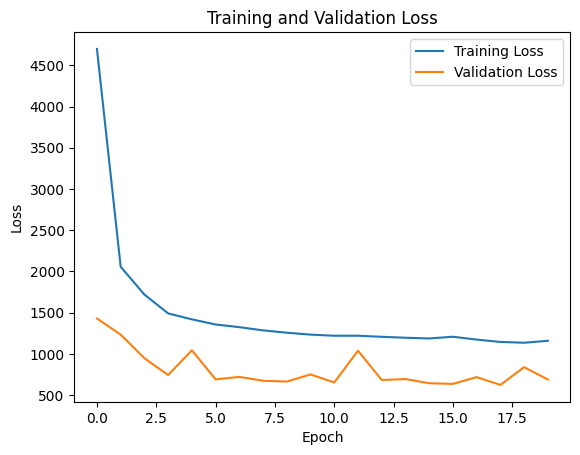

In [19]:
# Define the GRU model
gru_model = Sequential()
gru_model.add(GRU(units=64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
gru_model.add(Dropout(0.2))
gru_model.add(Dense(32, activation='relu'))
gru_model.add(Dense(1))

# Compile the model
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Add EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the GRU model
history = gru_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Plot loss and MAE curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()




In [20]:
print(test_data.columns)  # Check the columns in the test data


Index(['Unit', 'Time', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3',
       'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_7', 'Sensor_8', 'Sensor_9',
       'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15',
       'Sensor_17', 'Sensor_20', 'Sensor_21'],
      dtype='object')


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate GRU Model
y_val_pred_gru = gru_model.predict(X_val)
mae_gru = mean_absolute_error(y_val, y_val_pred_gru)
print(f"GRU MAE on Validation Set: {mae_gru}")

rmse_gru = np.sqrt(mean_squared_error(y_val, y_val_pred_gru))
print(f"GRU RMSE on Validation Set: {rmse_gru}")

r2_gru = r2_score(y_val, y_val_pred_gru)
print(f"GRU R^2 Score on Validation Set: {r2_gru}")


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
GRU MAE on Validation Set: 18.08774569893433
GRU RMSE on Validation Set: 24.956159046403872
GRU R^2 Score on Validation Set: 0.8148301287902762


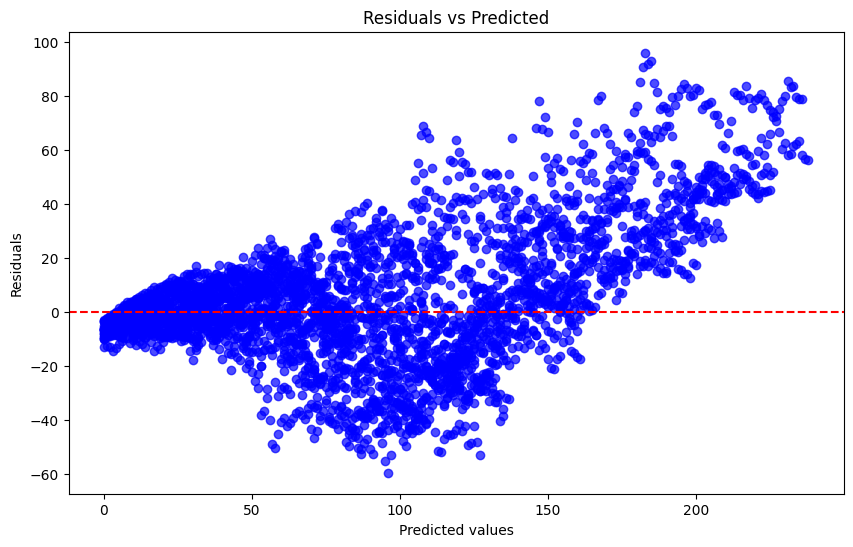

In [23]:
import matplotlib.pyplot as plt

# Calculate residuals
residuals = y_val - y_val_pred_gru.flatten()


# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_val, residuals, color='blue', alpha=0.7)


plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()


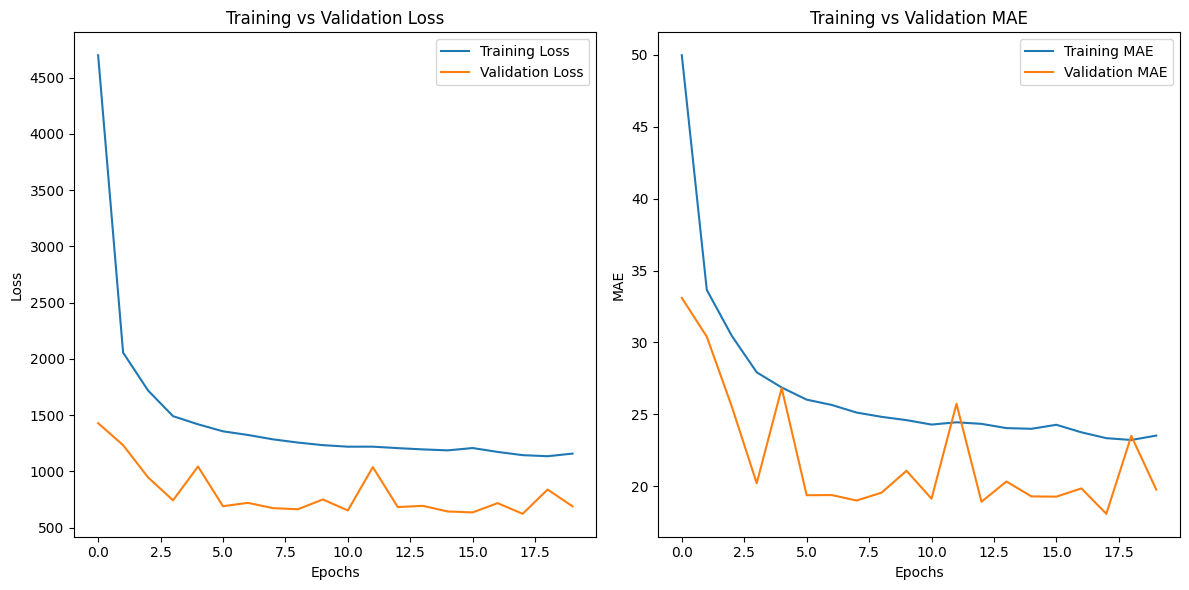

In [ ]:
# Assuming 'history' is the object returned by model.fit()
# History object contains 'loss', 'val_loss', 'mae', 'val_mae'

# Plot training & validation loss
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# MAE plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()


In [26]:
#save the model
gru_model.save('gru_model.keras')
#save the scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']